# GP Solver with `JAX` or `numpy`

This notebook shows how to use `src_numpy` and `src_jax` to:
1. Generate a synthetic stellar lightcurve
2. Fit a GP model with `GPSolver`
3. Compute the log-likelihood and predict the GP mean
4. Compare NumPy vs JAX performance

In [1]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../..")

## 1. Generate Synthetic Data

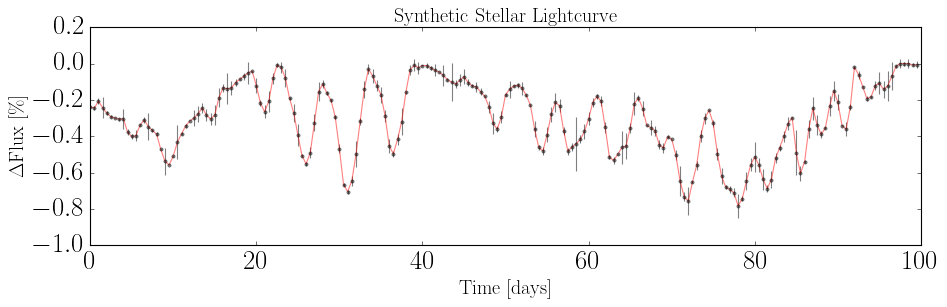

200 observations


In [2]:
from src_numpy.starspot import LightcurveModel

np.random.seed(42)

theta_true = dict(peq=5.0, kappa=0.3, inc=np.pi/3, nspot=40,
                  lspot=10.0, tau=5.0, alpha_max=0.05, fspot=0.)

lc = LightcurveModel(**theta_true, tsim=100, tsamp=0.5,
                     lat=[-np.pi/2, np.pi/2], long=[0, 2*np.pi])

tobs = lc.t
flux = lc.flux
flux_err = np.abs(np.random.normal(0, 0.2 * np.std(flux), flux.shape))

plt.figure(figsize=[12, 4])
plt.errorbar(tobs, flux * 100 - 100, yerr=flux_err * 100, fmt=".k", capsize=0, alpha=0.5)
plt.plot(tobs, flux * 100 - 100, color="r", alpha=0.5)
plt.xlabel("Time [days]", fontsize=18)
plt.ylabel(r"$\Delta$Flux [\%]", fontsize=18)
plt.title("Synthetic Stellar Lightcurve", fontsize=18)
plt.tight_layout()
plt.show()
print(f"{len(tobs)} observations")

## 2. Fit GP with `src_numpy`

In [3]:
from src_numpy.gp_solver import GPSolver as GPSolverNumpy

t0 = time.time()
gp_np = GPSolverNumpy(tobs, flux, flux_err, theta_true)
t_build_np = time.time() - t0

t0 = time.time()
loglike_np = gp_np.log_likelihood()
t_ll_np = time.time() - t0

print(f"[numpy] build:         {t_build_np:.3f} s")
print(f"[numpy] log-likelihood: {t_ll_np:.3f} s  →  {loglike_np:.2f}")

[numpy] build:         0.138 s
[numpy] log-likelihood: 0.000 s  →  1108.41


## 3. Fit GP with `src_jax`

Choose which device to run JAX computations (`cpu` or `gpu`)

In [ ]:
import os
os.environ["JAX_ENABLE_X64"] = "True"
DEVICE = "gpu"
os.environ["JAX_PLATFORMS"] = DEVICE
        
from src_jax.gp_solver import GPSolver as GPSolverJAX

t0 = time.time()
gp_jax = GPSolverJAX(tobs, flux, flux_err, theta_true)
t_build_jax = time.time() - t0

# First call triggers JIT compilation
_ = gp_jax.log_likelihood()

t0 = time.time()
loglike_jax = gp_jax.log_likelihood()
t_ll_jax = time.time() - t0

print(f"[jax]   build:          {t_build_jax:.3f} s")
print(f"[jax]   log-likelihood:  {t_ll_jax:.3f} s  →  {float(loglike_jax):.2f}")

[jax]   build:          0.320 s
[jax]   log-likelihood:  0.001 s  →  1108.41


## 4. GP Prediction

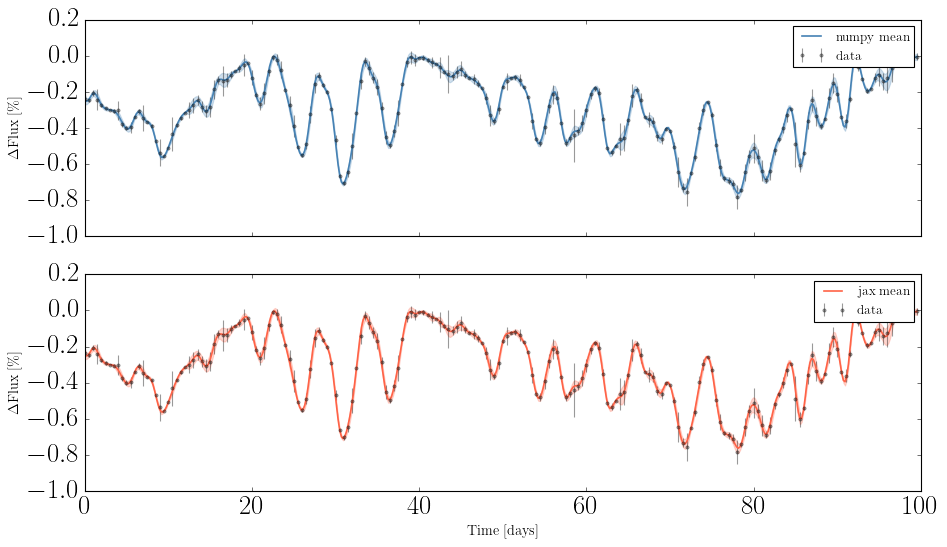

In [7]:
xpred = np.linspace(tobs.min(), tobs.max(), 500)

mu_np, var_np = gp_np.predict(xpred, return_cov=False)
mu_jax, var_jax = gp_jax.predict(xpred, return_cov=False)

std_np = np.sqrt(np.asarray(var_np))
std_jax = np.sqrt(np.asarray(var_jax))

fig, axes = plt.subplots(2, 1, figsize=[12, 7], sharex=True)

for ax, mu, std, label, color in zip(
        axes,
        [mu_np, mu_jax],
        [std_np, std_jax],
        ["numpy", "jax"],
        ["steelblue", "tomato"]):
    ax.errorbar(tobs, flux * 100 - 100, yerr=flux_err * 100,
                fmt=".k", capsize=0, alpha=0.4, label="data")
    ax.plot(xpred, np.asarray(mu) * 100 - 100, color=color, lw=1.5, label=f"{label} mean")
    ax.fill_between(xpred,
                    (np.asarray(mu) - std) * 100 - 100,
                    (np.asarray(mu) + std) * 100 - 100,
                    alpha=0.25, color=color)
    ax.set_ylabel(r"$\Delta$Flux [\%]", fontsize=13)
    ax.legend(fontsize=12)

axes[-1].set_xlabel("Time [days]", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Kernel / ACF

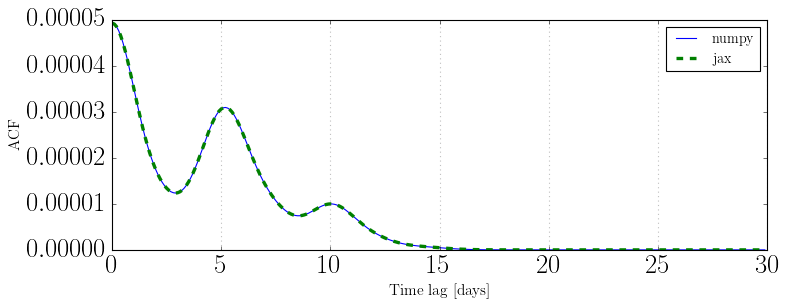

In [17]:
tlags = np.arange(0, 30, 0.1)

acf_np  = gp_np.compute_kernel(tlags)
acf_jax = gp_jax.compute_kernel(tlags)

plt.figure(figsize=[10, 4])
plt.plot(tlags, acf_np, label="numpy", lw=1)
plt.plot(tlags, np.asarray(acf_jax), label="jax", lw=3, ls="--")
for ii in range(1, 7):
    plt.axvline(ii * theta_true["peq"], color="gray", ls=":", alpha=0.5)
plt.axhline(0, color="gray", ls="-", alpha=0.3)
plt.xlabel("Time lag [days]", fontsize=14)
plt.ylabel("ACF", fontsize=14)
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

## 6. Find MAP Estimate

Optimize the GP hyperparameters by maximizing the log-posterior.

In [20]:
theta0 = dict(peq=4.0, kappa=0.1, inc=np.pi/4,
              lspot=8.0, tau=3.0, nspot=20, alpha_max=0.1, fspot=0.0)

free_keys = ["peq", "kappa", "inc", "lspot", "tau", "sigma_k"]

# numpy
t0 = time.time()
theta_map_np, result_np = gp_np.find_map(theta0=theta0, keys=free_keys)
print(f"[numpy] MAP in {time.time()-t0:.2f} s")

# jax
t0 = time.time()
theta_map_jax, result_jax = gp_jax.find_map(theta0=theta0, keys=free_keys)
print(f"[jax]   MAP in {time.time()-t0:.2f} s")

print("\nParameter       true      numpy MAP  jax MAP")
print("-" * 50)
for k in free_keys:
    tv = theta_true.get(k, float('nan'))
    nv = theta_map_np.get(k, float('nan'))
    jv = theta_map_jax.get(k, float('nan'))
    print(f"{k:<14}  {tv:8.4f}   {nv:8.4f}   {jv:8.4f}")

[numpy] MAP in 37.09 s
[jax]   MAP in 5.05 s

Parameter       true      numpy MAP  jax MAP
--------------------------------------------------
peq               5.0000     5.3930     7.3448
kappa             0.3000     0.1305     0.1594
inc               1.0472     1.0520     0.9222
lspot            10.0000     7.6089     9.3803
tau               5.0000     3.1403     3.0420
sigma_k              nan     0.0014     0.0026
